In [ ]:
'''
Decision Tree

'''

In [14]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt


In [16]:
CSV_PATH = "mushrooms.csv"
df = pd.read_csv(CSV_PATH)
print("First 5 rows:\n", df.head(), "\n")


First 5 rows:
   class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p        

  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p          w   
1       

In [17]:
target = 'class' if 'class' in df.columns else df.columns[0]
X = df.drop(columns=[target])
y = df[target]

In [18]:
X_encoded = pd.get_dummies(X, drop_first=True)
y_encoded = y.map(lambda v: 1 if str(v).lower() in ['p', 'positive', 'yes', 'true', '1'] else 0)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [20]:
clf = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [21]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.999

Confusion Matrix:
 [[842   0]
 [  2 781]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [22]:
importances = pd.Series(clf.feature_importances_, index=X_encoded.columns)
top_features = importances.sort_values(ascending=False).head(10)
print("\nTop 10 Important Features:\n", top_features)


Top 10 Important Features:
 odor_n                        0.530740
bruises_t                     0.216440
stalk-root_c                  0.066431
spore-print-color_r           0.051282
stalk-root_r                  0.047419
gill-spacing_w                0.046914
stalk-surface-below-ring_y    0.028964
stalk-root_b                  0.005668
cap-surface_g                 0.004467
cap-shape_c                   0.001675
dtype: float64


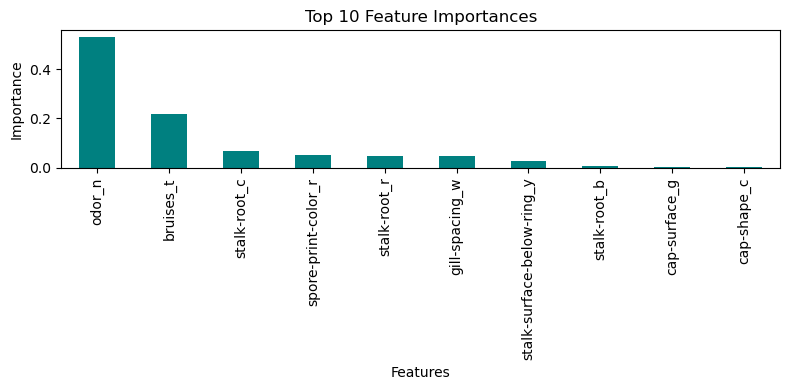

In [23]:
plt.figure(figsize=(8, 4))
top_features.plot(kind='bar', color='teal')
plt.title("Top 10 Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

[Text(0.5, 0.9166666666666666, 'odor_n <= 0.5\nentropy = 0.999\nsamples = 6499\nvalue = [3366, 3133]\nclass = Edible'),
 Text(0.23076923076923078, 0.75, 'bruises_t <= 0.5\nentropy = 0.665\nsamples = 3673\nvalue = [637, 3036]\nclass = Poisonous'),
 Text(0.15384615384615385, 0.5833333333333334, 'entropy = 0.0\nsamples = 2603\nvalue = [0, 2603]\nclass = Poisonous'),
 Text(0.3076923076923077, 0.5833333333333334, 'stalk-root_c <= 0.5\nentropy = 0.974\nsamples = 1070\nvalue = [637, 433]\nclass = Edible'),
 Text(0.23076923076923078, 0.4166666666666667, 'stalk-root_r <= 0.5\nentropy = 0.928\nsamples = 659\nvalue = [226, 433]\nclass = Poisonous'),
 Text(0.15384615384615385, 0.25, 'gill-spacing_w <= 0.5\nentropy = 0.6\nsamples = 507\nvalue = [74, 433]\nclass = Poisonous'),
 Text(0.07692307692307693, 0.08333333333333333, 'entropy = 0.0\nsamples = 433\nvalue = [0, 433]\nclass = Poisonous'),
 Text(0.23076923076923078, 0.08333333333333333, 'entropy = 0.0\nsamples = 74\nvalue = [74, 0]\nclass = Edibl

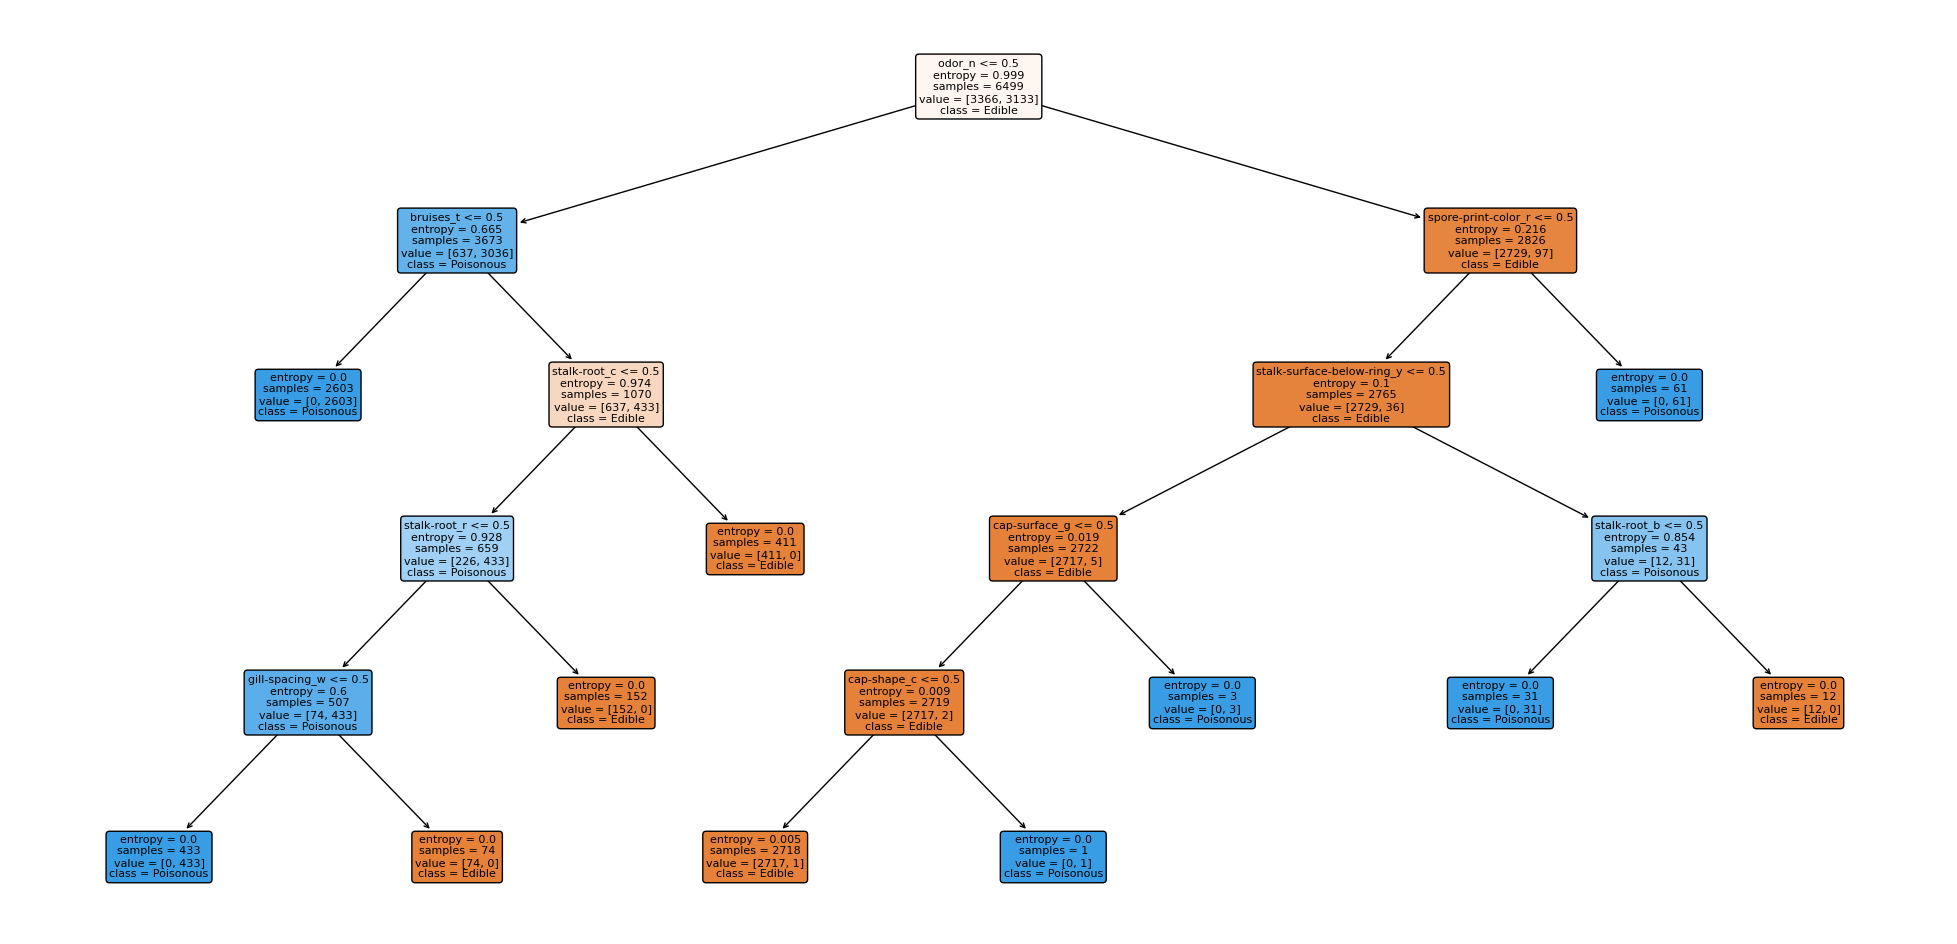

In [24]:
plt.figure(figsize=(25, 12))
plot_tree(
    clf,
    feature_names=X_encoded.columns,
    class_names=['Edible', 'Poisonous'],
    filled=True,
    rounded=True,
    fontsize=8
)